In [52]:
# ============================================
# OIBSIP - Data Science Task 1
# Iris Flower Classification
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add species names
df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))
)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully!
Rows: 150
Columns: 6


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [53]:
# ============================================
# 2. Dataset Overview
# ============================================

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (150, 6)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [54]:
# Statistical summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [55]:
# ============================================
# 3. Missing Value Check
# ============================================

print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [56]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


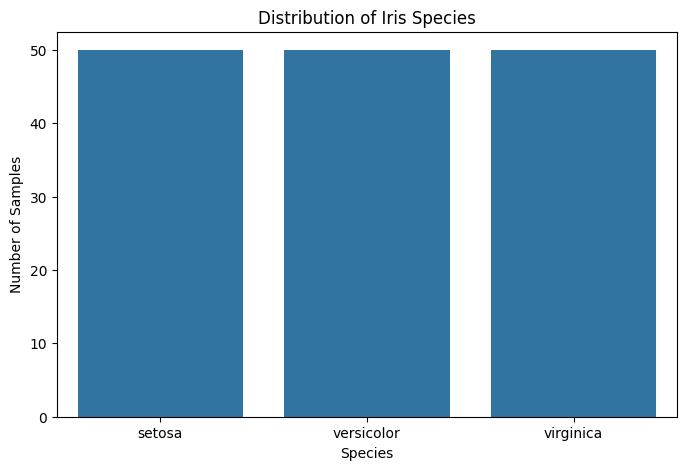

In [57]:
# ============================================
# 4. Class Distribution
# ============================================

print(df["species"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.show()

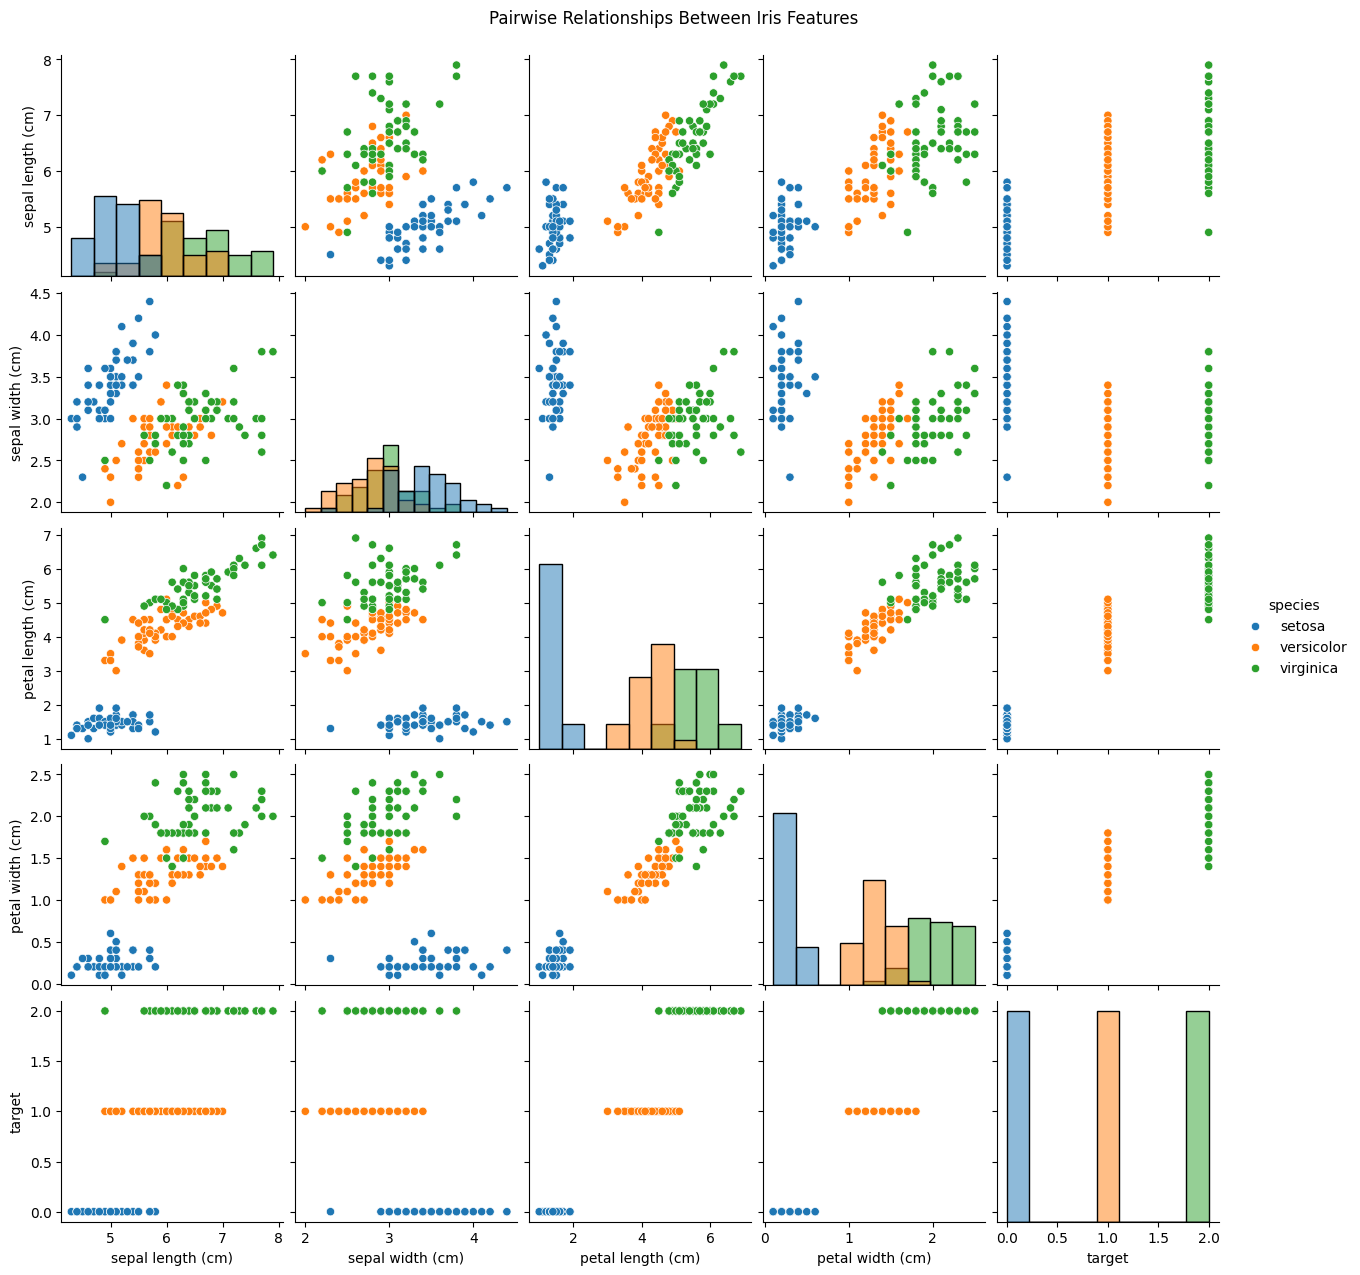

In [58]:
# ============================================
# 5. Pairplot
# ============================================

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationships Between Iris Features",
    y=1.02
)

plt.show()

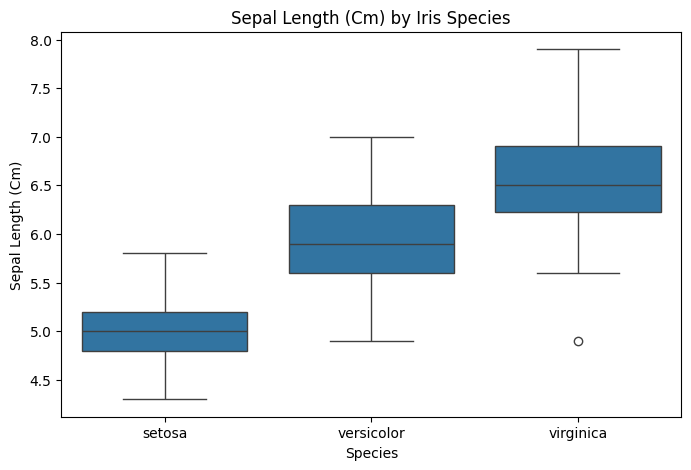

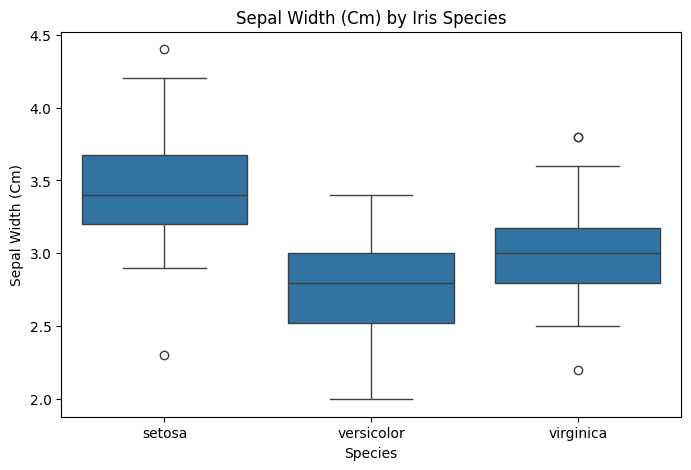

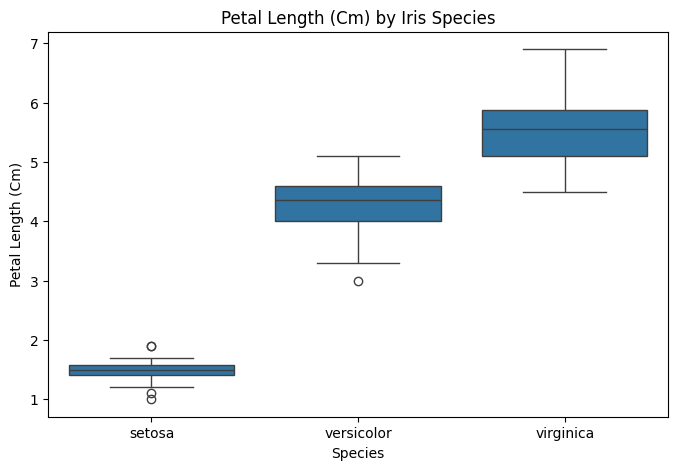

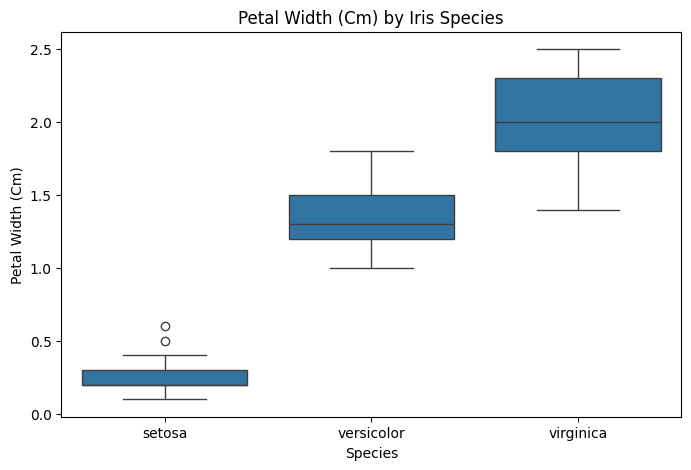

In [59]:
# ============================================
# 6. Box Plots
# ============================================

features = iris.feature_names

for feature in features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )

    plt.title(f"{feature.title()} by Iris Species")
    plt.xlabel("Species")
    plt.ylabel(feature.title())

    plt.show()

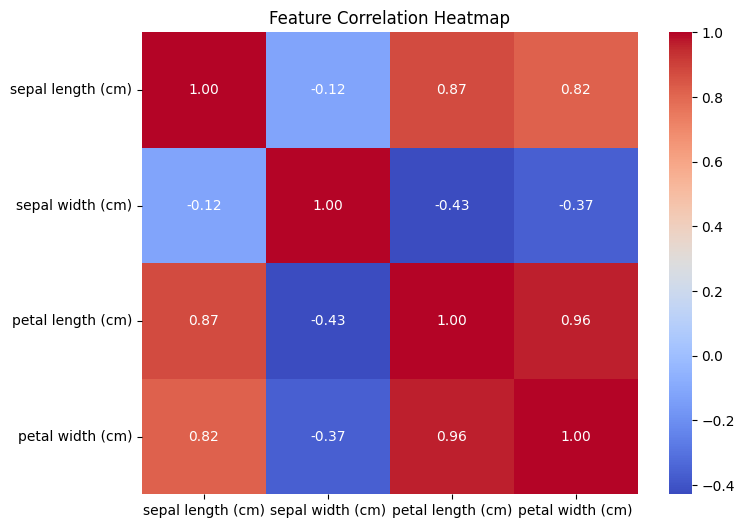

In [60]:
# ============================================
# 7. Correlation Heatmap
# ============================================

numeric_features = df[iris.feature_names]

correlation = numeric_features.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [61]:
# ============================================
# 8. Feature and Target Preparation
# ============================================

X = df[iris.feature_names]
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [62]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [63]:
# ============================================
# 9. Model Training
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("All models trained successfully!")

All models trained successfully!


In [64]:
# ============================================
# 10. Model Evaluation
# ============================================

from sklearn.metrics import accuracy_score

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
1,K-Nearest Neighbors,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


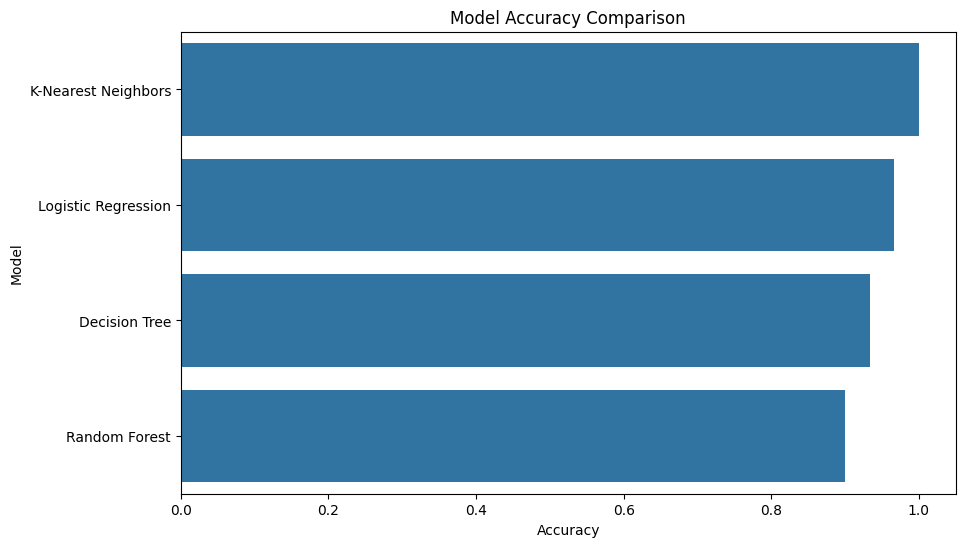

In [65]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1.05)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

In [66]:
# ============================================
# 11. Classification Reports
# ============================================

from sklearn.metrics import classification_report

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=iris.target_names
        )
    )

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

K-Nearest Neighbors
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.

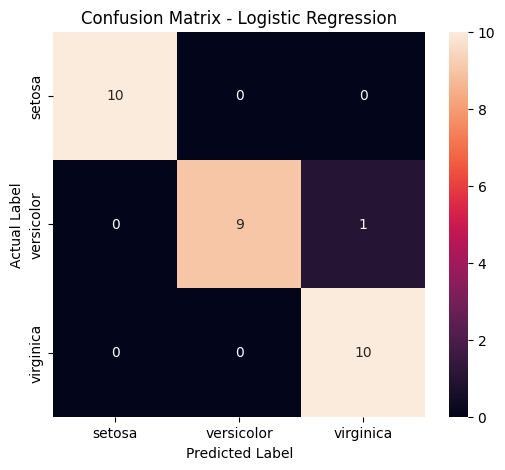

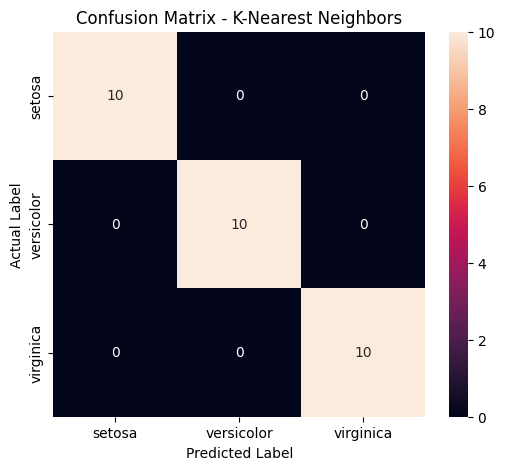

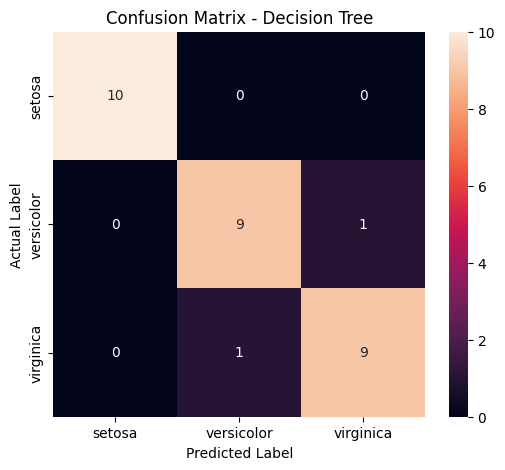

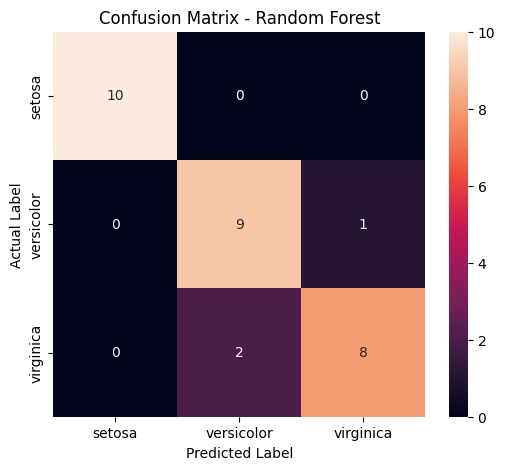

In [67]:
# ============================================
# 12. Confusion Matrices
# ============================================

from sklearn.metrics import confusion_matrix

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

In [68]:
# ============================================
# 13. Best Model Selection
# ============================================

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print(
    "Best Accuracy:",
    f"{results_df.iloc[0]['Accuracy']:.4f}"
)

Best Model: K-Nearest Neighbors
Best Accuracy: 1.0000


In [69]:
# ============================================
# 14. Cross-Validation
# ============================================

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in trained_models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    by="Mean CV Accuracy",
    ascending=False
)

cv_df

,Model,Mean CV Accuracy,Std
0,Logistic Regression,0.973333,0.024944
1,K-Nearest Neighbors,0.973333,0.024944
3,Random Forest,0.966667,0.021082
2,Decision Tree,0.953333,0.033993


In [70]:
# ============================================
# 15. Feature Importance
# ============================================

rf_model = trained_models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

             Feature  Importance
3   petal width (cm)    0.437185
2  petal length (cm)    0.431466
0  sepal length (cm)    0.116349
1   sepal width (cm)    0.015000


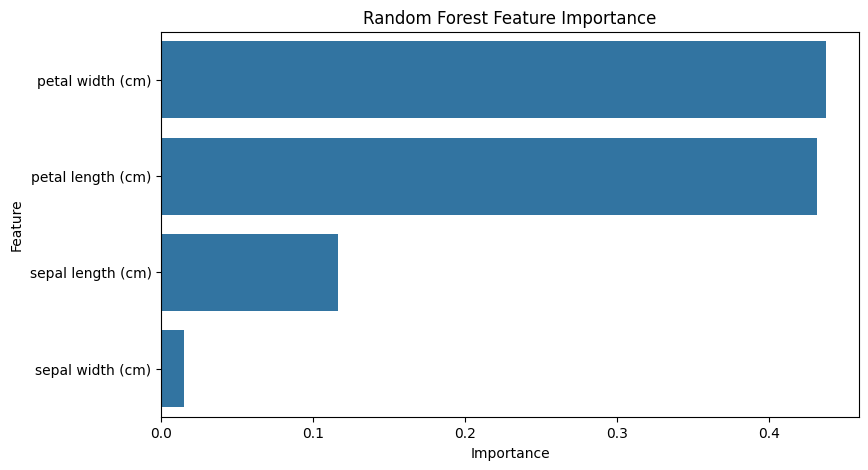

In [71]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [72]:
# ============================================
# 16. Final Model Selection
# ============================================

best_model_name = cv_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("🏆 Best Model:", best_model_name)
print(
    "Cross-Validation Accuracy:",
    f"{cv_df.iloc[0]['Mean CV Accuracy']:.4f}"
)

🏆 Best Model: Logistic Regression
Cross-Validation Accuracy: 0.9733


In [73]:
# ============================================
# 17. Final Test Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_predictions = best_model.predict(X_test)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted"
)

final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted"
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted"
)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_results

,Metric,Score
0,Accuracy,0.966667
1,Precision,0.969697
2,Recall,0.966667
3,F1-Score,0.966583


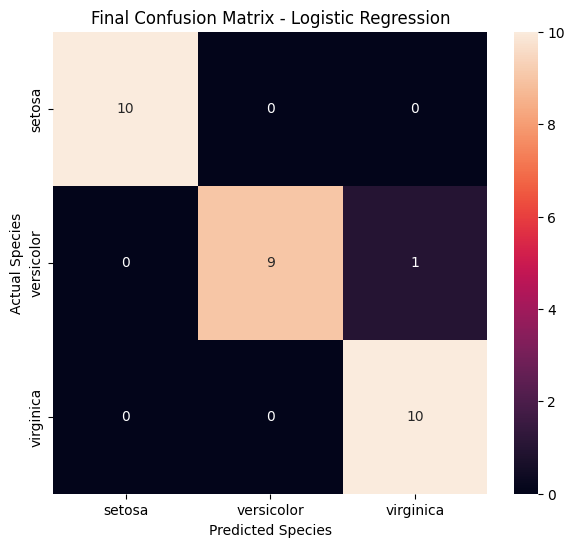

In [74]:
# ============================================
# 18. Final Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title(f"Final Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

## Conclusion

The Iris Flower Classification project successfully explored the Iris dataset through exploratory data analysis and developed multiple machine learning classification models.

Four classification algorithms were evaluated: Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest. Their performance was compared using accuracy, classification metrics, confusion matrices, and cross-validation.

The best-performing model was selected based on cross-validation performance. Feature importance analysis was also performed to understand which flower measurements contributed most to the predictions.

The final model can classify Iris flowers into Setosa, Versicolor, and Virginica based on sepal and petal measurements.

In [75]:
# ============================================
# 19. New Flower Prediction
# ============================================

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

prediction = best_model.predict(new_flower)[0]

predicted_species = iris.target_names[prediction]

print("Input Measurements:")
print(new_flower)

print("\n🌸 Predicted Species:",
      predicted_species.title())

Input Measurements:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2

🌸 Predicted Species: Setosa


# 🌸 Iris Flower Classification

### Oasis Infobyte Internship — Data Science Task 1

**Objective:**  
Build and evaluate machine learning classification models to predict the species of an Iris flower based on its sepal and petal measurements.

**Technologies Used:**  
Python • Pandas • NumPy • Matplotlib • Seaborn • Scikit-learn

**Models Used:**  
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest

## 1. Dataset Loading and Overview

The Iris dataset is a well-known dataset used for demonstrating classification algorithms. It contains measurements of iris flowers and three different species: Setosa, Versicolor, and Virginica.

In [76]:
# Load the Iris dataset
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target
df["target"] = iris.target

# Add species names
df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [77]:
# Dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [78]:
# Statistical summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [79]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Duplicate Rows: 1


## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, and relationships within the Iris dataset before building machine learning models.

In [80]:
# Species distribution

print("Number of samples in each species:")
print(df["species"].value_counts())

Number of samples in each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


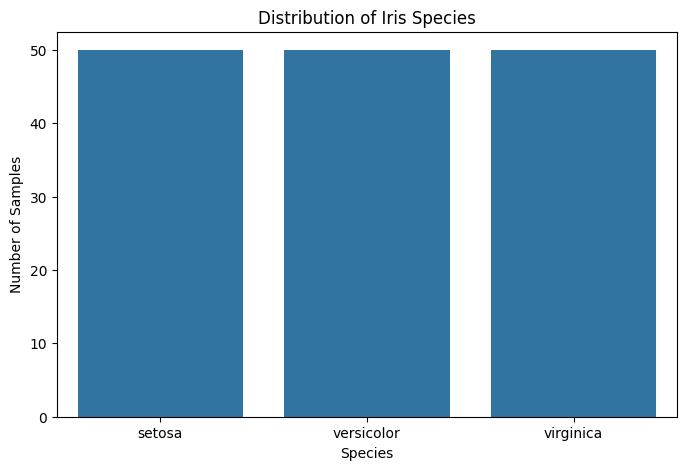

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

### Pairwise Feature Relationships

A pairplot is used to visualize relationships between the numerical features and observe how well the Iris species can be separated.

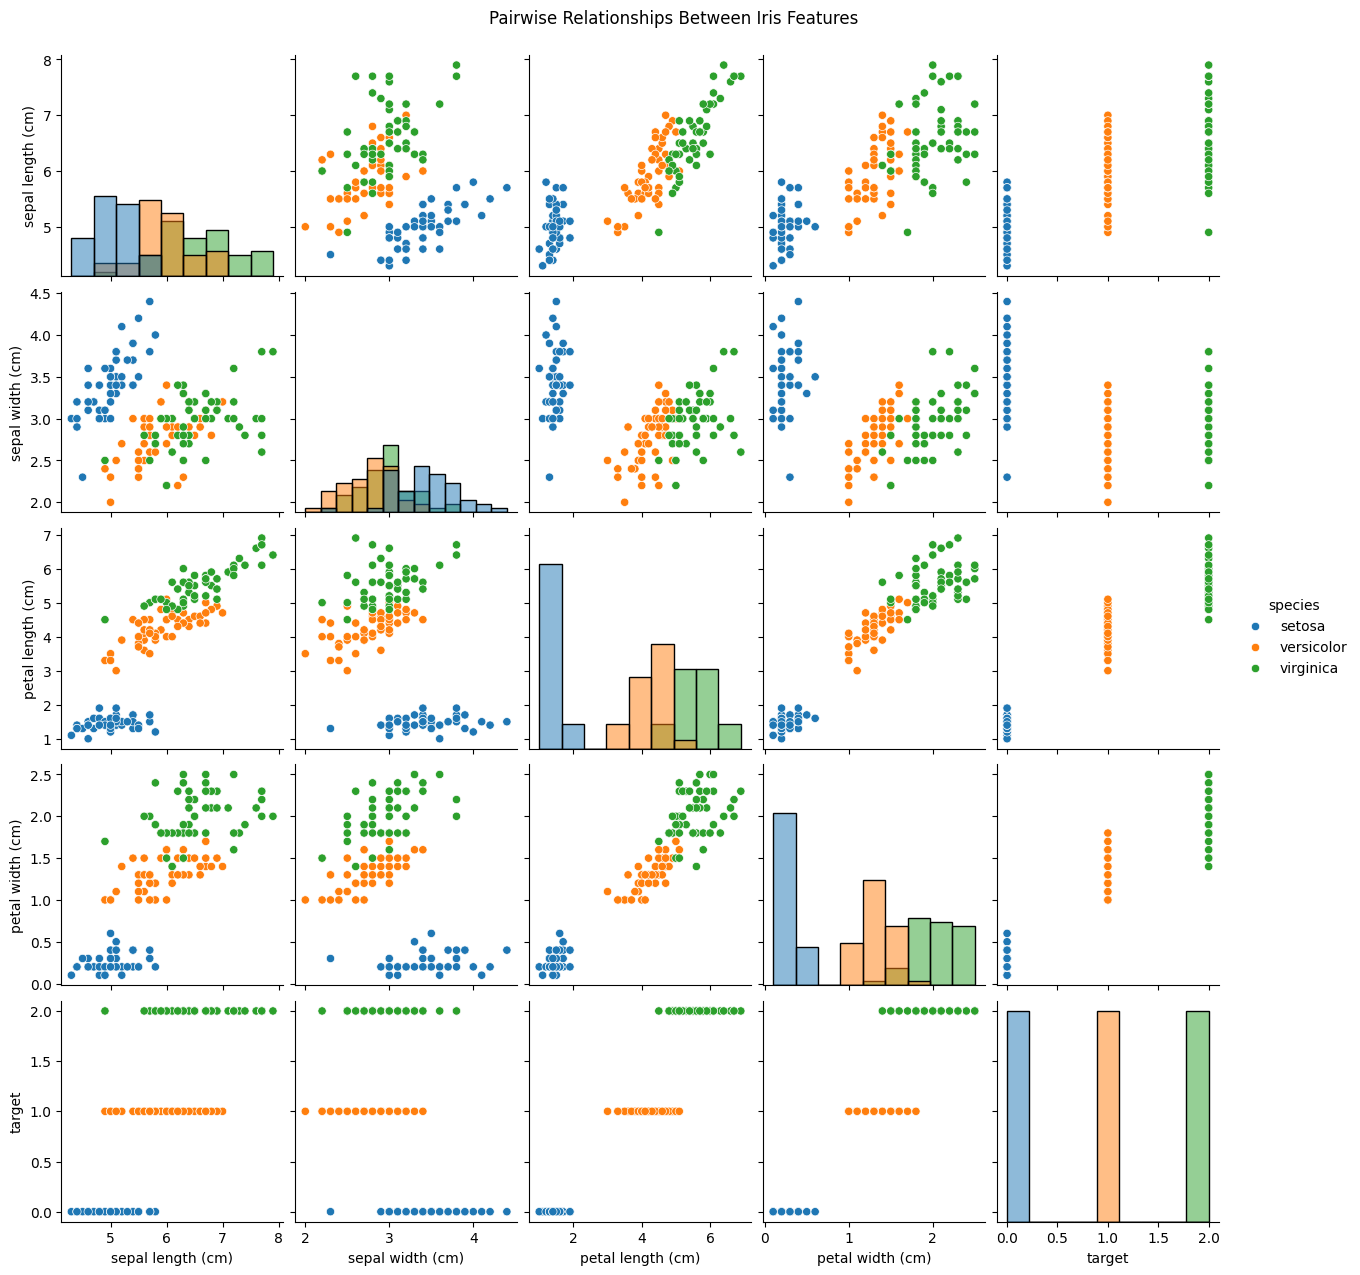

In [82]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationships Between Iris Features",
    y=1.02
)

plt.show()

### Feature Distribution by Species

Box plots are used to compare the distribution of each numerical feature across the three Iris species and identify differences in their measurements.

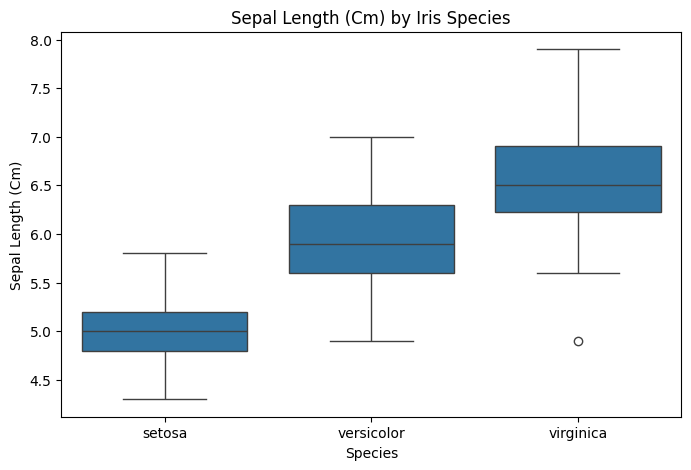

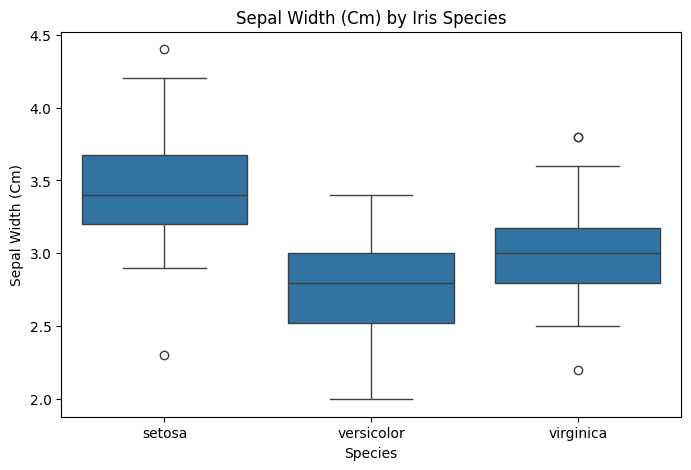

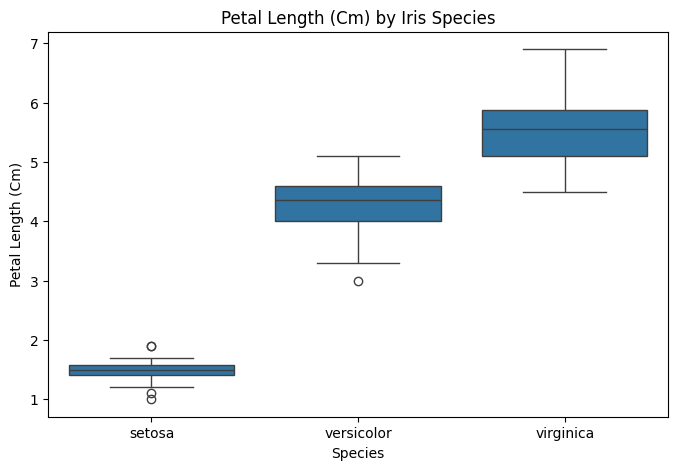

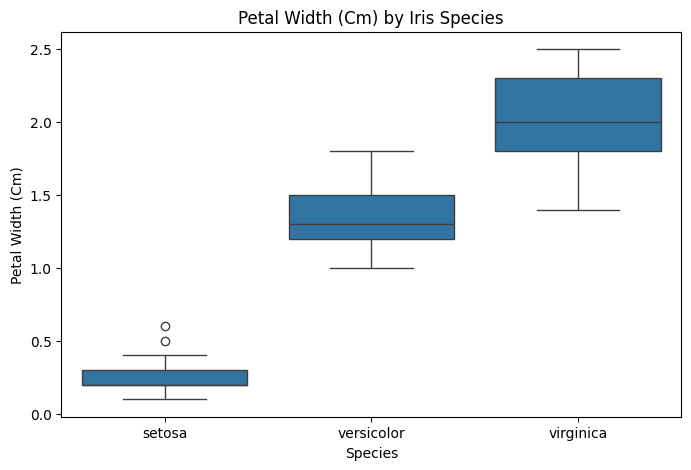

In [83]:
features = iris.feature_names

for feature in features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )

    plt.title(f"{feature.title()} by Iris Species")
    plt.xlabel("Species")
    plt.ylabel(feature.title())

    plt.show()

### Feature Correlation

A correlation heatmap is used to understand the relationships between the numerical features in the dataset.

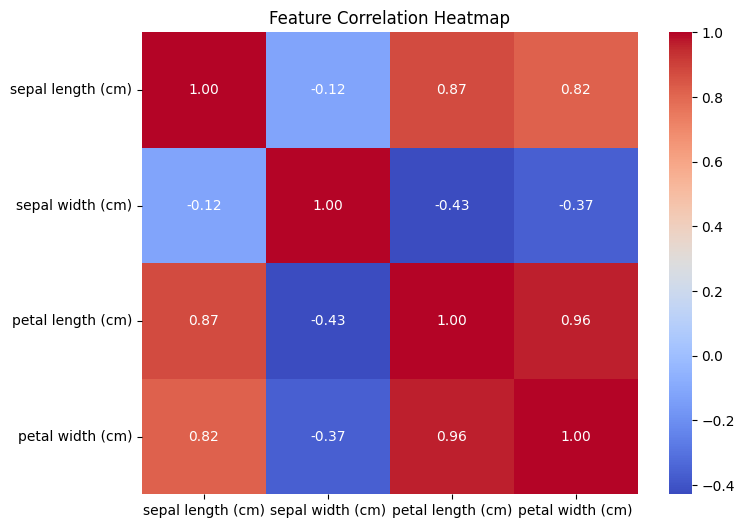

In [84]:
numeric_features = df[iris.feature_names]

correlation = numeric_features.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

## 3. Feature Selection

The Iris dataset contains four numerical features: sepal length, sepal width, petal length, and petal width.

Based on the exploratory analysis, petal length and petal width show strong relationships with the Iris species. However, all four features are retained for the initial model training so that the classifiers can use the complete available information.

In [85]:
# ============================================
# Feature Selection
# ============================================

X = df[iris.feature_names]
y = df["target"]

print("Selected Features:")
print(X.columns.tolist())

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Selected Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Feature Shape: (150, 4)
Target Shape: (150,)


### Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the classification models, while the testing data is used to evaluate their performance on unseen samples.

In [86]:
# ============================================
# Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


### Why an 80/20 Split?

An 80/20 split provides enough data for model training while reserving a separate portion of the dataset for unbiased evaluation. The `stratify` parameter ensures that all three Iris species remain proportionally represented in both sets.

## 4. Model Training

Four classification algorithms are trained and evaluated to determine which model performs best for Iris flower classification.

In [87]:
# ============================================
# Model Training
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("All models trained successfully!")

All models trained successfully!


### Model Accuracy Comparison

The trained models are evaluated on the test dataset. Accuracy is used as an initial metric to compare their classification performance.

In [88]:
# ============================================
# Model Accuracy Comparison
# ============================================

from sklearn.metrics import accuracy_score

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy
0,K-Nearest Neighbors,1.000000
1,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


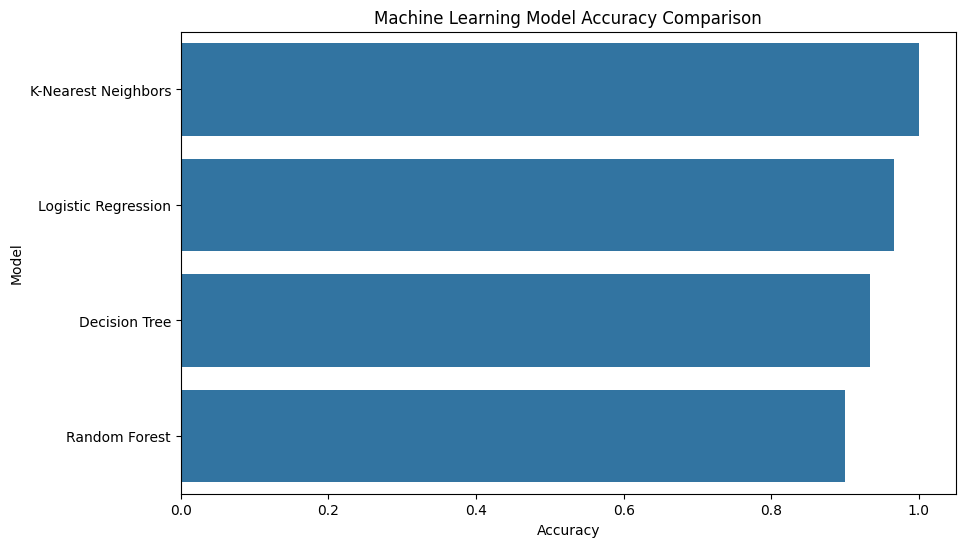

In [89]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1.05)
plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

## 5. Detailed Model Evaluation

The classification models are evaluated using precision, recall, F1-score, and confusion matrices in addition to accuracy. These metrics provide a more detailed understanding of model performance for each Iris species.

In [90]:
# ============================================
# Classification Reports
# ============================================

from sklearn.metrics import classification_report

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=iris.target_names
        )
    )

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

K-Nearest Neighbors
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.

### Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each Iris species. Correct predictions appear along the diagonal, while off-diagonal values represent classification errors.

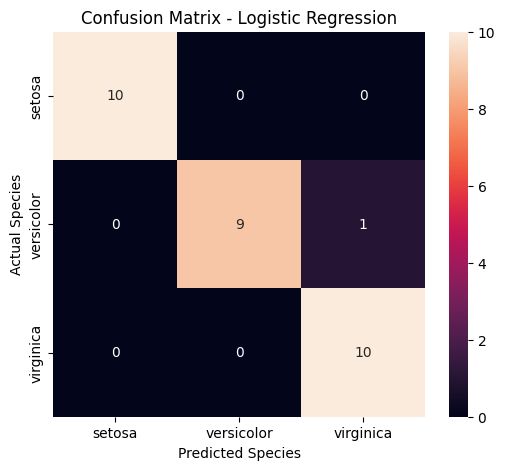

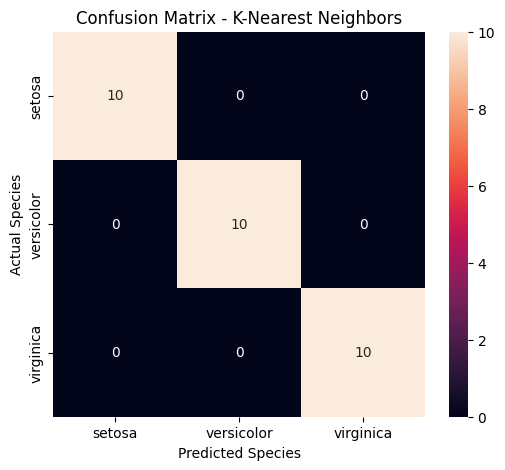

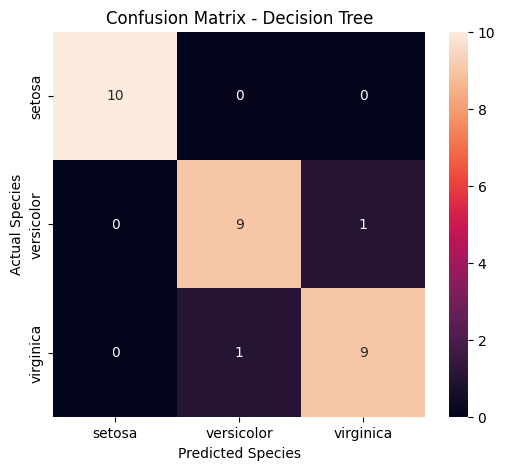

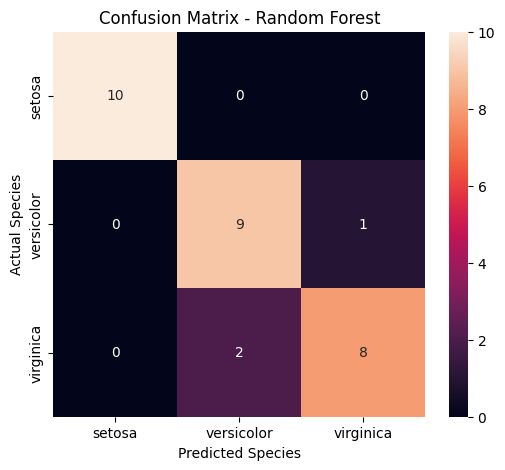

In [91]:
# ============================================
# Confusion Matrices
# ============================================

from sklearn.metrics import confusion_matrix

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Species")
    plt.ylabel("Actual Species")

    plt.show()

## 6. Best Model Selection

The best-performing model is selected based on its test accuracy. Cross-validation will also be used later to check whether the model performs consistently across different data splits.

In [92]:
# ============================================
# Best Model Based on Test Accuracy
# ============================================

best_test_model_name = results_df.iloc[0]["Model"]
best_test_model = trained_models[best_test_model_name]

best_test_accuracy = results_df.iloc[0]["Accuracy"]

print("🏆 Best Model:", best_test_model_name)
print("Test Accuracy:", f"{best_test_accuracy:.4f}")

🏆 Best Model: K-Nearest Neighbors
Test Accuracy: 1.0000


### Cross-Validation

Five-fold cross-validation is used to evaluate the consistency of each model across multiple training and validation splits.

In [93]:
# ============================================
# Cross-Validation
# ============================================

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in trained_models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    by="Mean CV Accuracy",
    ascending=False
).reset_index(drop=True)

cv_df

,Model,Mean CV Accuracy,Standard Deviation
0,Logistic Regression,0.973333,0.024944
1,K-Nearest Neighbors,0.973333,0.024944
2,Random Forest,0.966667,0.021082
3,Decision Tree,0.953333,0.033993


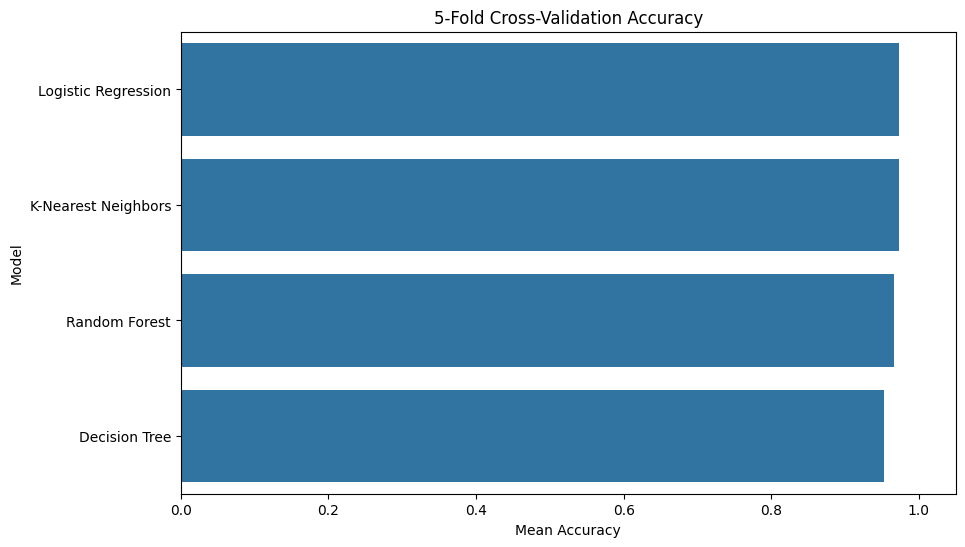

In [94]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_df,
    x="Mean CV Accuracy",
    y="Model"
)

plt.xlim(0, 1.05)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")

plt.show()

## 7. Feature Importance

Feature importance helps identify which input features contribute most to the Random Forest classification decisions.

In [95]:
# ============================================
# Feature Importance - Random Forest
# ============================================

rf_model = trained_models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df

,Feature,Importance
0,petal width (cm),0.437185
1,petal length (cm),0.431466
2,sepal length (cm),0.116349
3,sepal width (cm),0.015000


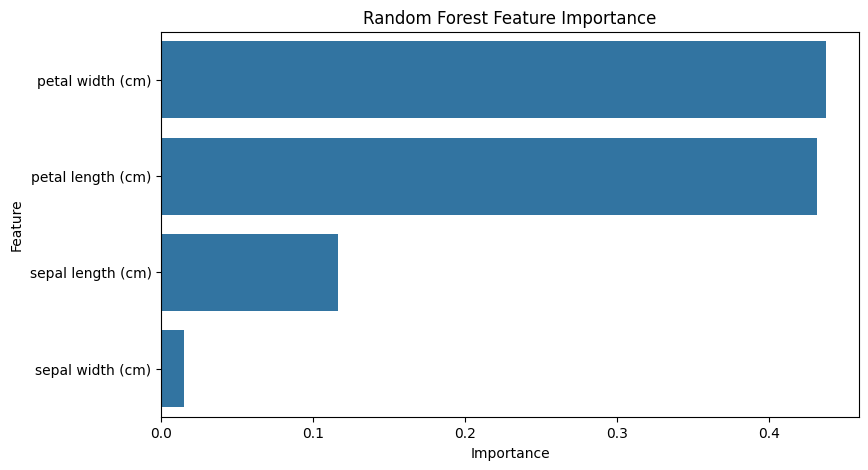

In [96]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 8. New Flower Prediction

The trained model is tested with a new set of flower measurements to demonstrate how the classification system can be used for prediction.

In [97]:
# ============================================
# New Flower Prediction
# ============================================

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

prediction = best_test_model.predict(new_flower)[0]

predicted_species = iris.target_names[prediction]

print("Input Measurements:")
display(new_flower)

print(
    "\n🌸 Predicted Species:",
    predicted_species.title()
)

Input Measurements:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2



🌸 Predicted Species: Setosa


In [98]:
# ============================================
# Prediction Probabilities
# ============================================

probabilities = best_test_model.predict_proba(new_flower)[0]

probability_df = pd.DataFrame({
    "Species": iris.target_names,
    "Probability": probabilities
})

probability_df

,Species,Probability
0,setosa,1.0
1,versicolor,0.0
2,virginica,0.0


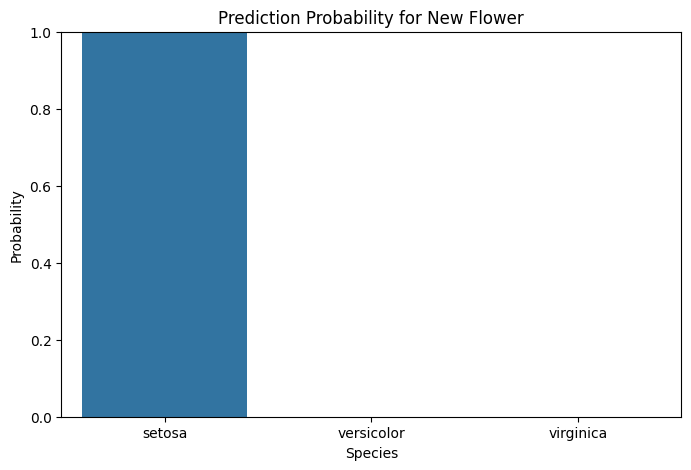

In [99]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=probability_df,
    x="Species",
    y="Probability"
)

plt.ylim(0, 1)
plt.title("Prediction Probability for New Flower")
plt.xlabel("Species")
plt.ylabel("Probability")

plt.show()

## 9. Conclusion

The Iris Flower Classification project successfully explored the Iris dataset and developed multiple machine learning classification models.

Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest were trained and compared using accuracy, precision, recall, F1-score, confusion matrices, and 5-fold cross-validation.

The best-performing model was selected based on the evaluation results. Feature importance analysis was also performed to understand the contribution of different flower measurements.

Finally, the trained model was used to predict the species of a new flower based on its sepal and petal measurements. The project demonstrates how machine learning can be applied to classify flowers into Setosa, Versicolor, and Virginica.